In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
import data_management

In [2]:
file_path = "/home/onyxia/work/data/FOIL2013"

In [3]:
parquet_files = [os.path.join(file_path, f"trip_data_{i}.parquet") for i in range(3, 12)]

In [5]:
df_list = [pd.read_parquet(file) for file in parquet_files]
df = pd.concat(df_list, ignore_index=True)

In [5]:
print("Aperçu des données :")
print(df.head())
print (df.columns)

Aperçu des données :
      pickup_datetime    dropoff_datetime  passenger_count  trip_time_in_secs  \
0 2013-03-01 00:00:04 2013-03-01 00:19:03                1               1138   
1 2013-03-01 00:00:18 2013-03-01 00:12:11                1                712   
2 2013-03-01 00:00:18 2013-03-01 00:14:24                1                845   
3 2013-03-01 00:00:23 2013-03-01 00:14:56                1                872   
4 2013-03-01 00:00:35 2013-03-01 00:05:44                1                308   

   trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
0     23013.6192        -73.776703        40.645164         -73.913925   
1      5310.8352        -73.987343        40.752056         -73.965340   
2      7242.0480        -73.991493        40.726444         -73.980865   
3     14484.0960        -73.873108        40.774094         -73.960930   
4      2092.1472        -73.990562        40.750927         -73.982880   

   dropoff_latitude  
0         40.772614  
1  

In [6]:
traffic_data = pd.read_csv("/home/onyxia/work/data/automated_traffic_volume_counts.csv")

In [20]:
traffic_data.head()

,RequestID,Boro,year,month,day,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction,geometry,datetime
0,32970,Queens,2021,4,30,2,0,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
1,32970,Queens,2021,4,30,2,15,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
2,32970,Queens,2021,4,30,2,30,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
3,32970,Queens,2021,4,30,2,45,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
4,32970,Queens,2021,4,30,3,0,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30


In [7]:
df.columns

Index(['pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_time_in_secs', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'],
      dtype='object')

In [ ]:
df = date_taxis(df)

In [ ]:
df_cleaned = df.drop_duplicates()

/tmp/ipykernel_49451/185834521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")


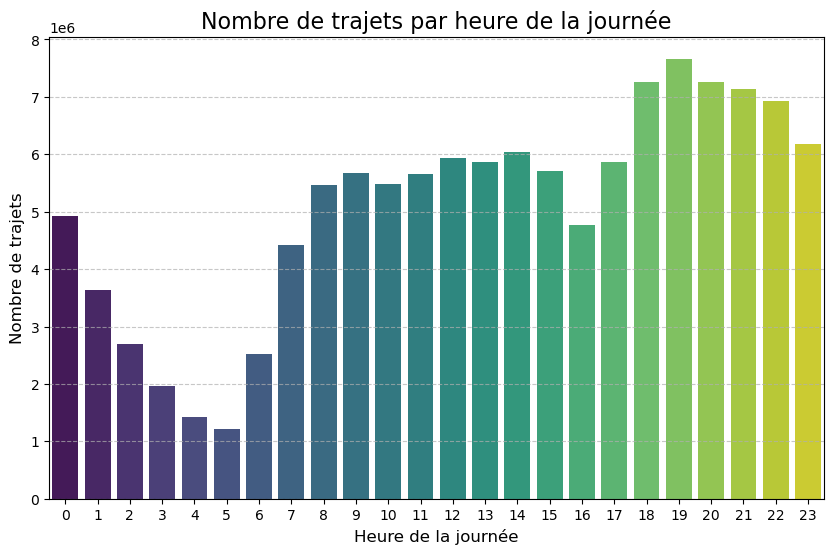

In [8]:
hourly_trips = df['pickup_hour'].value_counts().sort_index()

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")
plt.title("Nombre de trajets par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_49451/2072531354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")


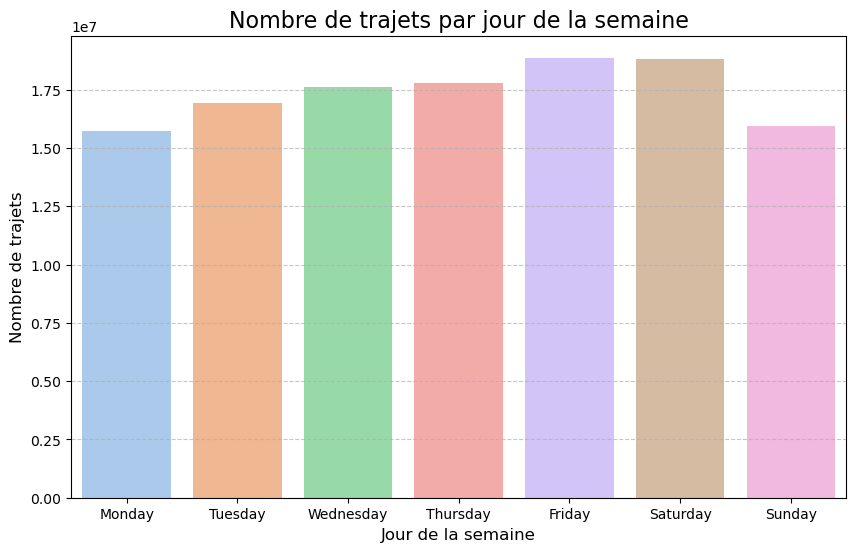

In [11]:
# Compter les trajets par jour de la semaine
weekly_trips = df['pickup_day'].value_counts()

# Ordonner les jours de la semaine
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trips = weekly_trips.reindex(ordered_days)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")
plt.title("Nombre de trajets par jour de la semaine", fontsize=16)
plt.xlabel("Jour de la semaine", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

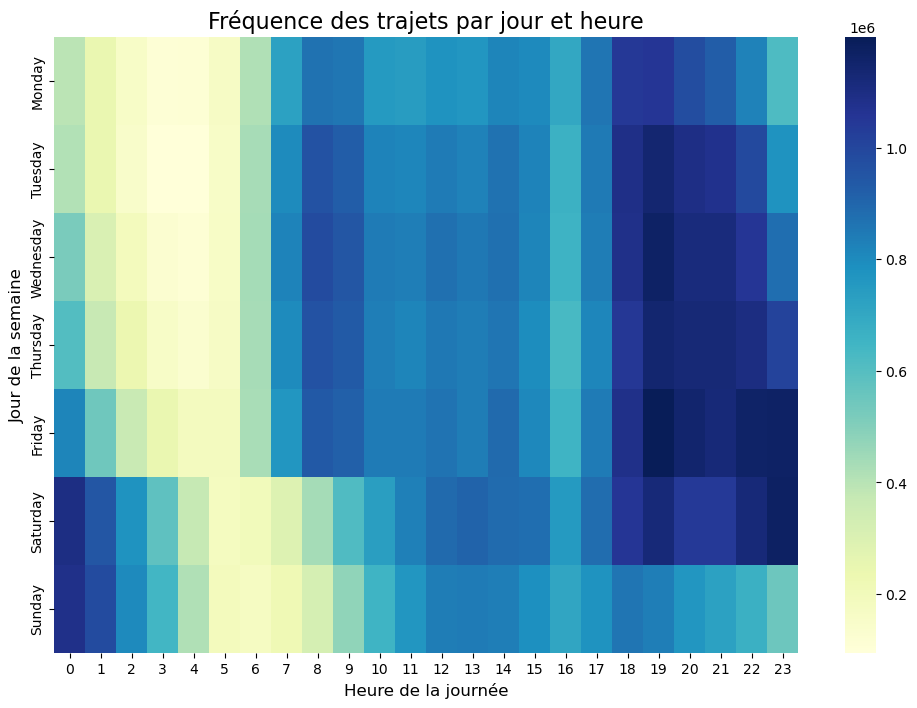

In [12]:
# Grouper les trajets par jour de la semaine et heure
heatmap_data = df.groupby(['pickup_day', 'pickup_hour']).size().unstack()

# Réordonner les jours
heatmap_data = heatmap_data.reindex(index=ordered_days)

# Visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Fréquence des trajets par jour et heure", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Jour de la semaine", fontsize=12)
plt.show()

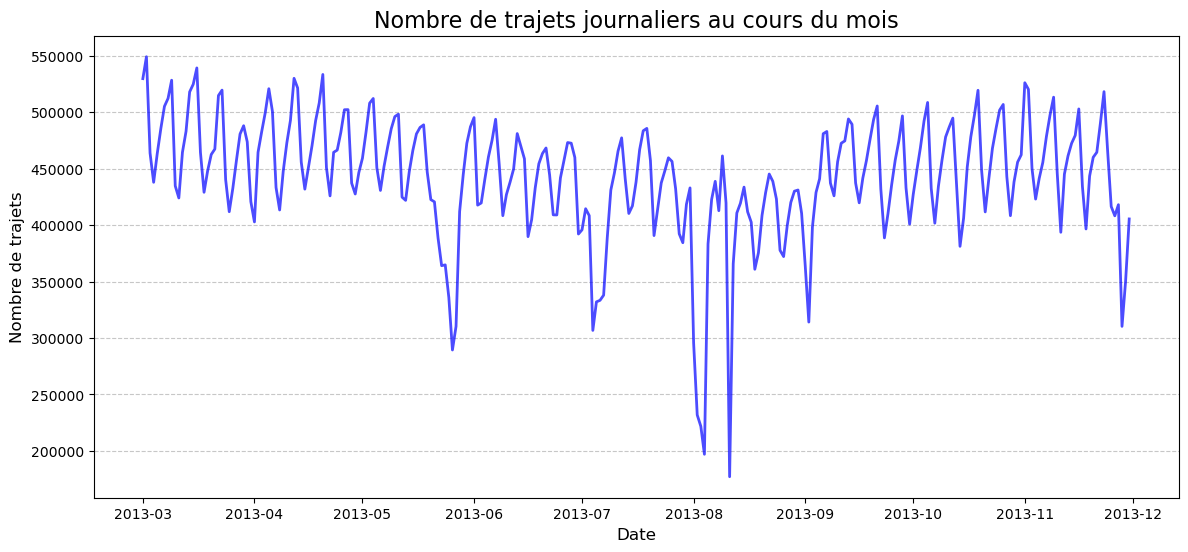

In [13]:
# Compter les trajets par jour du mois
daily_trips = df.groupby('pickup_date').size()

# Visualisation
plt.figure(figsize=(14, 6))
daily_trips.plot(color="blue", alpha=0.7, linewidth=2)
plt.title("Nombre de trajets journaliers au cours du mois", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [52]:
# Renommer les colonnes pour qu'elles soient explicites
traffic_data = traffic_data.rename(columns={'Yr': 'year', 'M': 'month', 'D': 'day', 'HH' : 'hour', 'MM' : 'minute'})

# Vérification des colonnes
print(traffic_data.columns)


Index(['RequestID', 'Boro', 'year', 'month', 'day', 'hour', 'minute', 'Vol',
       'SegmentID', 'WktGeom', 'street', 'fromSt', 'toSt', 'Direction',
       'geometry', 'datetime'],
      dtype='object')


In [53]:
# Conversion en datetime
traffic_data['datetime'] = pd.to_datetime(traffic_data[['year', 'month', 'day', 'hour', 'minute']])
print(traffic_data[['year', 'month', 'day', 'datetime']].head())


   year  month  day            datetime
0  2021      4   30 2021-04-30 02:00:00
1  2021      4   30 2021-04-30 02:15:00
2  2021      4   30 2021-04-30 02:30:00
3  2021      4   30 2021-04-30 02:45:00
4  2021      4   30 2021-04-30 03:00:00


In [12]:
import geopandas as gpd
from shapely import wkt

In [13]:
traffic_data['geometry'] = traffic_data['WktGeom'].apply(wkt.loads)


In [14]:
gdf = gpd.GeoDataFrame(traffic_data, geometry='geometry')

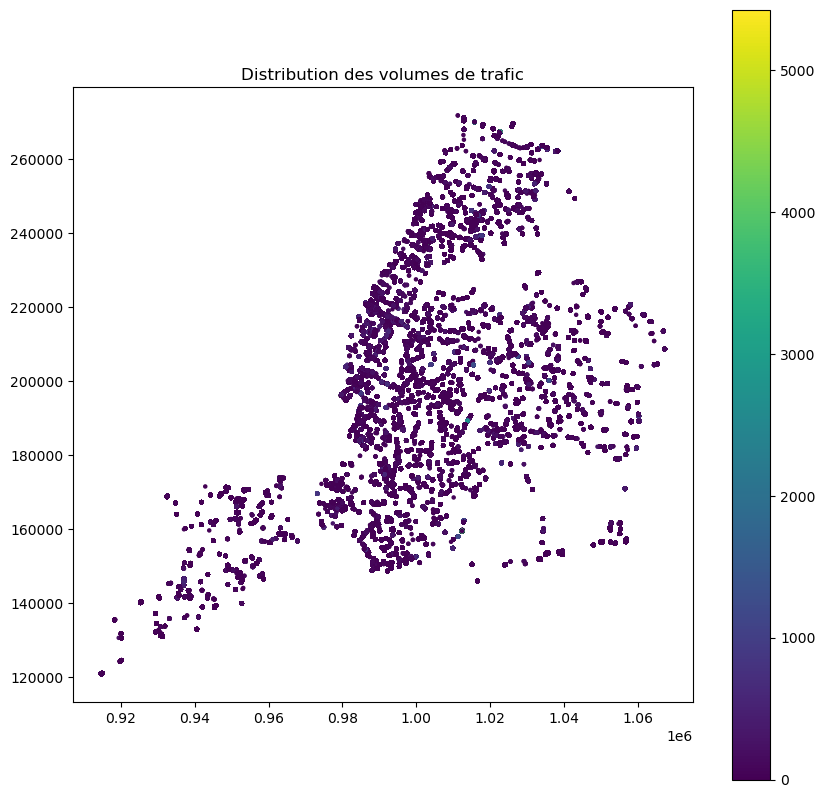

In [15]:
ax = gdf.plot(column='Vol', legend=True, cmap='viridis', markersize=5, figsize=(10, 10))
plt.title('Distribution des volumes de trafic')
plt.show()

In [50]:
if gdf.crs is None:
    # Si le CRS n'est pas défini, on l'assigne manuellement à EPSG:4326 (latitude/longitude)
    gdf.set_crs("EPSG:2263", allow_override=True, inplace=True)
elif gdf.crs != "EPSG:2263":
    # Si le CRS est défini mais n'est pas EPSG:4326, on le convertit
    gdf = gdf.to_crs("EPSG:2263")

# Agrégation des données par rue
agg_gdf = gdf.groupby('street').agg({
    'Vol': 'sum',  # Somme des volumes de trafic
    'geometry': 'first'  # Garder la première géométrie (généralement le centroïde)
}).reset_index()

In [31]:
# Agrégation par "street"
aggregated_df = traffic_data.groupby('street').agg(
    Vol=('Vol', 'sum'),  # Additionner les volumes
    Boro=('Boro', 'first'),  # Prendre la première valeur pour "Boro"
    SegmentID=('SegmentID', 'first'),  # Prendre la première valeur pour "SegmentID"
    WktGeom=('WktGeom', 'first'),  # Prendre la première valeur pour "WktGeom"
    fromSt=('fromSt', 'first'),  # Prendre la première valeur pour "fromSt"
    toSt=('toSt', 'first'),  # Prendre la première valeur pour "toSt"
    Direction=('Direction', 'first'),  # Prendre la première valeur pour "Direction"
    datetime=('datetime', 'min')  # Prendre la première date (vous pouvez utiliser 'min' ou 'max' selon vos besoins)
).reset_index()

In [49]:
traffic_data

,RequestID,Boro,year,month,day,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction,geometry,datetime
0,32970,Queens,2021,4,30,2,0,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
1,32970,Queens,2021,4,30,2,15,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
2,32970,Queens,2021,4,30,2,30,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
3,32970,Queens,2021,4,30,2,45,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
4,32970,Queens,2021,4,30,3,0,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,POINT (997407.0998491726 208620.92612708386),2021-04-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712600,17447,Queens,2014,6,28,15,0,6,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,POINT (1037356.1 200863.7),2014-06-28
1712601,17447,Queens,2014,6,28,15,15,7,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,POINT (1037356.1 200863.7),2014-06-28
1712602,17447,Queens,2014,6,28,15,30,8,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,POINT (1037356.1 200863.7),2014-06-28
1712603,17447,Queens,2014,6,28,15,45,8,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,POINT (1037356.1 200863.7),2014-06-28


In [32]:
from folium import Choropleth
from IPython.display import IFrame

In [51]:

m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

for idx, row in agg_gdf.iterrows():
    # Utiliser le centroïde de la géométrie pour le placement du cercle
    if row['geometry'].is_valid:  # Vérifier la validité de la géométrie
        centroid = row['geometry'].centroid
        traffic_volume = row['Vol']
        radius = min(traffic_volume / 100, 50)  # La taille du cercle est proportionnelle au volume de trafic, avec un maximum de rayon de 50

        # Ajouter un cercle sur la carte
        folium.CircleMarker(
            location=[centroid.y, centroid.x],  # Utiliser le centroïde de la géométrie pour le placement du cercle
            radius=radius,  # Taille du cercle
            color='blue',  # Couleur du cercle
            fill=True,
            fill_color='blue',  # Couleur de remplissage
            fill_opacity=0.6,  # Opacité du remplissage
            tooltip=f"Street: {row['street']}<br>Traffic Volume: {traffic_volume}"  # Tooltip pour chaque cercle
        ).add_to(m)

# Afficher la carte directement dans le notebook
m